CLASSIFICAZIONE CON BOW E SVM

Classificare con BoW e SVM significa usare due componenti diversi insieme.

Bag of Words → trasforma il testo in numeri
SVM → usa quei numeri per decidere la classe

Quindi BoW non classifica da solo. E' la rappresentazione numerica del testo. La classificazione vera la fa la Support Vector Machine (SVM)

Prendiamo un esempio:
"vorrei ordinare 500 pezzi"        → ORDINE
"la merce è arrivata danneggiata"  → RECLAMO
"chiediamo quotazione per 100 pz"  → OFFERTA
"confermiamo ordine di 300 pezzi"  → ORDINE

Il primo passagio è Bag of Words
Supponiamo che il vocabolario sia:
ordine, pezzi, merce, danneggiata, quotazione, confermiamo

Le frasi diventano vettori numerici 
                              ordine pezzi merce danneggiata quotazione confermiamo

"ordinare 500 pezzi"             0     1     0       0          0          0
"merce danneggiata"              0     0     1       1          0          0
"chiediamo quotazione..."        0     1     0       0          1          0
"confermiamo ordine..."          1     1     0       0          0          1

Questi vettori diventano input per SVM

La pipeline completa è:
TESTO  -> ountVectorizer -> BAG OF WORDS -> MATRICE NUMERICA -> SVM -> CLASSE

Per esempio:
"la merce è danneggiata" -> [0,0,1,1,0,0,...] -> SVM -> RECLAMO

La SVM prende i vettori e cerca di trovare una separazione matematica tra le diverse categorie
SVM cerca un linea che separi le diverse categorie. In due dimensioni è una linea, in 3 dimensioni è un piano.
Con migliaia di feature Bow parliamo di ipepiano
Quindi SVM cerca l'iperpiano che separa meglio le classi.
Ma non cerca una separazione qualsiasi, cerca quella con il margine più ampio possibile, cerca di massimizzare la distanza tra le varie categorie
La SVM cerca di lasciare più spazio possibile tra il confine e gli esempio più vicini delle due classi. 
, fare
Gli esempi più importanti (le frasi più importanti) sono quelle che contribuiscono, maggiormente a definire il confine decisionale.
Nel testo la cosa funziona molto bene perchè Bow produce vettori molto sparsi.
Esempio:
20.000 parole -> 20.000 feature
ma ogni mail magari ha solo 50 parole
quindi ha moltissimi zeri.
Le SVM lineari lavorano particolarmente bene proprio con dati di questo tipo.
In scikit-learn puoi fare:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC

testi = [
    "vorrei ordinare 500 pezzi",
    "confermiamo ordine di 300 pezzi",
    "la merce ricevuta è danneggiata",
    "il prodotto presenta un difetto",
    "chiediamo quotazione per 100 pezzi",
    "potete inviarci la vostra offerta"
]
categorie = [
    "ordine",
    "ordine",
    "reclamo",
    "reclamo",
    "offerta",
    "offerta"
]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(testi)
model = LinearSVC()
model.fit(X, categorie)

ed hai un modello addestrato partendo dalle frasi e dalle feature indicate in testi ed in categorie
Poi arriva una nuova mail, devi utilizzare lo stesso vettore (vectorizer), fare il transform e poi la predizione con .predic

nuova_mail = ["vorremmo ordinare 200 pezzi"]
X_nuova = vectorizer.transform(nuova_mail)  #non devi fare .fitransfor altrimenti cambi il vocabolario
predizione = model.predict(X_nuova)
print(predizione)

In un progetto vero però, al posto del puro BoW useresti TF-IDF + SVM quindi:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X = vectorizer.fit_transform(testi)
model = LinearSVC()
model.fit(X, categorie)

Perchè TF-IDF tende ad essere più informativo del semplice conteggio.
TF-IDF cerca di dare più importanza a termini utili e moeno a quelli troppo comuni, inoltre puoi aggiungre n-gram e quindi SVM non riceve solo richiesta e poi offerta, ma anche 'richiesta offerta'

Come  facciamo a decidere, per esempoio se una recensione è positiva o se una mail è spam?
Immagina di dover tracciare una linea netta tra i due territori.

Come si gestisce un mondo con centinaio di coordinate?

Iperpiani ad Alta Dimensionalità
Trovare il confine ottimale tra i documenti
Quanto utiliziamo la rappresentazione Bag of Words, trasformiamo ogni doucmento in un punto all'interno di un iperspazio dove ogni dimensione corrisponde a una parola del vocabolario. 
Poichè il numero di parole può essere di migliaia, ci troviamo a gestire problemi in altissima dimensionalità
Le Support Vector Machines (SVM) sono particolarmente efficaci in questo contesto perchè cercano l'iperpaino che massimizza il margine di separazione tra le classi, garantendo una robustessa che altri modelli faticano a mantenere quando le feature superano il numero di campioni.

Ma tra infiniti possibili confini, quale dobbiamo scegliere

Massimizzare il Margine
La geometria della separazione lineare.
La genialtà sta nelle SPV, non ci accontentiamo di un confine qualunque, vogliamo la strada più larga possibile tra due gruppi di punti. i punti più vicini a questi confini sono i nostri Support Vector e sono loro i protagonisti. Un punto lontano da queste linee/confine, il modello non cambia, ma se spostiamo un support vector, l'intero sistema ruota.
Questo protegge il modello dal rumore dei dati rilevanti.

In un linguaggio naturale, la matrice Dcoumenti-Term è estremamente sparsa ( quasi tutta piena di 0). Le SVM accellono nel trovare confini che dipendono solo dai campioni più critici, ignorando il rumore delle parole irrilevanti.
Le SVM evitano la degradazione delle performance tipica dell'alta dimensionalità focalizzandosi sulla geometrica locale di support vectors.

Ottimizzazione del Margine
Minimizzazione della norma
Trovare l'iperpiano migliore equivale a minimizzare la norma del vettore dei pesi sotto vincoli di corretta classificazione. Questo processo geometrico assicura che il confine sia il più lontano  possibile da entrambi i gruppi di documeti.

Dataset Sbilanciati
Gestire la rarità nelle classi testuali.
Nei problemi reali di NLP, come la detection dello spam o l'analisi di sentiment, le classi raramente sono distrinuite in modo uniforme. E' comune avere migliaia di email lecite e solo poche decine di tentativi i phishing. Se addestraiamo una SVM standard, lei capirà che dire sempre 'è tutto normale' le garantisce un 90% di accuracy, ma quesot è per noi un fallimento, perchè l'unica mail 'errata' è passata come normale.
Un modello SVM standard, tenderebbe a favorire la classe maggioritaria, per minimizzare l'errore globale. E' possibile correggere questo comportamento agendo sulla funzione di costo per dare più importanza ai campioni della classe meno rappresentata.
 
Pesature e Bilanciamento
Usiamo il parametro Class Weight: assegna un costo di errore più alto quando il modello sbaglia la classificazione di un esempio raro. Se il modlelo sbaglia a classificare un esempio raro la punizione matematica che riceve è molto più alta rispetto allo sbaglio sulla classe più comune. Questo sposta fisicamente l'iper piano allontanandolo dalla classe meno rappresentata. Sacrifiamo poi un po di precisione globale, per ottenere una precisione più alta, in altre parole accettiamo qualche falso allarme, pur di non perder nemmeno un caso critico. 
In questi contetisti l'accuratezza piò essere una metrica bugiarda, se un medico dicesse a tutti 'lei sta bene' sarebe accuratissimo statisticamente, ma sarebbe un pessimo medico.
Per valutare un modello su dastaset sbilanciati, dobbiamo guardare la F1-Score, questa metrica bilancia il desiderio di essere precisi, con la necessità di non dimenticare nessuno.
Bilanciando poi il peso delle classi, risoviamo il pronlema delle classi sbilanciate

Ma come decidiamo il peso da dare ad ogni classe?

Assegnazione dei Pesi
Inversione delle frequenze.
Se la classe A è 10 volte più frequente della classe B, daremo alla classe B un peso 10 volte maggiore nella funzione di costo. in questo modo, durante l'addestramento, il gradiente riceve un segnale bilanciato. Ogni categoria avrà lo stesso impatto sulla decisione finale.
Per calcolare il peso ottimale, si divede il numero totale di campioni per il prodotto tra il numero di classi e la frequenza della classe specifica.
Questo garantisce che ogni classe contribuisca equamente alla funzione di costo finale.
Il peso della classe j assicura che il segnale dei campioni rari venga amplificato durante la discesa del gradiente.

Interpretazione dei coefficienti
Leggere il peso delle parole nella decisione.
A differenza dei modelli di Deep Learning black-box, le SVM lineari offronto un'altissima  interpretabilità. Ogni parola nel nostro vocabolario riceve un coefficiente numerico che indica il suo contributo alla classificazione finale.
Analizzando questi pesi, possiamo scoprire quali termini sono indicatori univoci di una categorie.
Questo processo non solo valida il modello, ma fornisce insight preziosi sulla natura dle linguaggio utilizzato dagli utenti.

Come distinguere tra parole che spingono verso il si e parole che spingono verso il no.
La conoscenza si estrae dai pesi.
Il valore assoluto del coefficiente indica quanto quella specifica parola è determinante per il confine di decisione (per il confine nell'iperpiano)
Se il valore è positivo e molto alto, significa che quella parola sposta la decisione verso la classe positiva.
La magnitudo poi ci dice quanto quel termine è determinante.

Analizzare i coefficiente è anche un test di salute del nostro modello.

Questa validazione semantica, ci permette di pulire ulterioremnte i nostir dati, rimuovendo parole che portano a decisioni errate.
Il modo migliore per farlo è visualizzare tutto graficamente.Non guardiamo lunghe tabelle di numeri, ma grafici a barre 

E' la base per costruire sistemi AI spiegabili ed affidabili



--- Addestramento SVM: Ricerca dell'Iperpiano Ottimale ---

Report Qualitativo (Accuracy vs Precision/Recall):
              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00        12
    Positivo       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17


Generazione del grafico dei poli semantici...


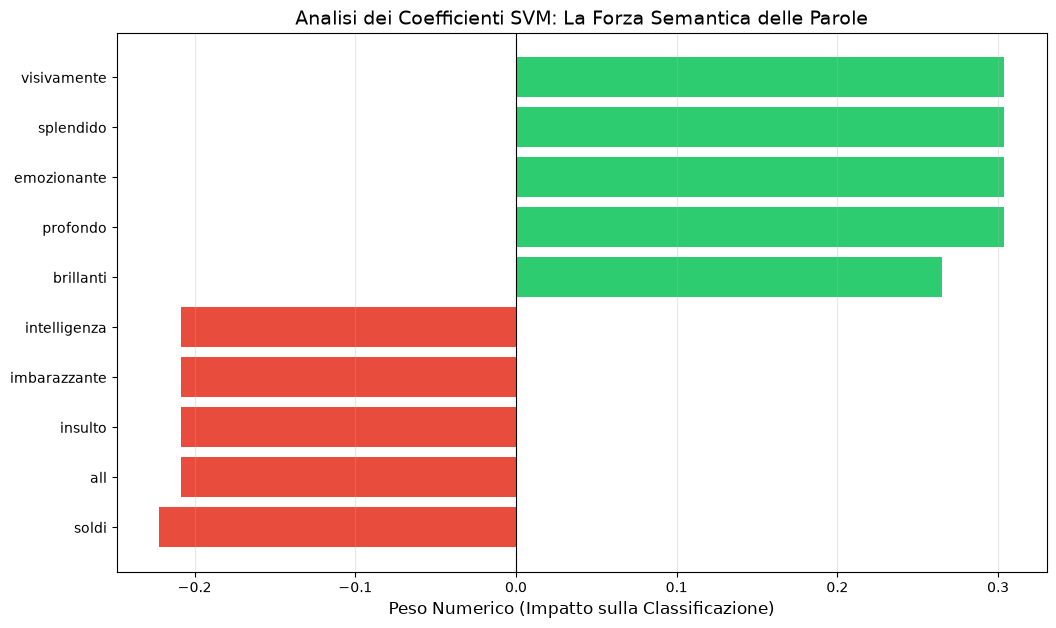

In [2]:
"""

SISTEMA: Sentiment Analysis con SVM Lineare (Pure Scikit-Learn)

ARCHITETTURA DEL CODICE:
1. DATA GENERATION: Creiamo testi grezzi (Input umano).
2. VECTORIZATION (Ponte): Trasformiamo il testo in coordinate numeriche (Input macchina).
3. MODELING (Il Cuore): L'SVM traccia l'iperpiano che separa i territori.
4. ANALYTICS (L'Interprete): Estraiamo i pesi per capire la logica del modello.

RELAZIONE TRA PARTI:
- Il 'vectorizer' definisce le dimensioni dello spazio in cui la 'svm' lavorerà.
- La 'svm' genera coefficienti che tornano al 'vectorizer' per essere associati alle parole.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

def genera_dati_didattici():
    """
    PUNTO DI PARTENZA: Creazione del Dataset.
    
    Relazione: Fornisce le stringhe di testo che il 'CountVectorizer' dovrà mappare.
    Creiamo volontariamente più negativi che positivi per testare la 'giustizia statistica'.
    """
    recensioni = [
        # --- CLASSE POSITIVA (1) - La minoranza ---
        "Un capolavoro assoluto, sceneggiatura e attori brillanti",
        "Emozionante, profondo e visivamente splendido",
        "Una delle migliori esperienze cinematografiche di sempre",
        "Regia magistrale e fotografia da togliere il fiato",
        "Un viaggio incredibile nei sentimenti umani, consigliatissimo",
        
        # --- CLASSE NEGATIVA (0) - La maggioranza ---
        "Noioso, prevedibile e recitato male",
        "Uno spreco di soldi, assolutamente sconsigliato",
        "Pessimo montaggio, trama inesistente e banale",
        "Terribile, non vedevo l'ora che finisse",
        "Delusione totale, regia mediocre",
        "Brutto, lento e senza alcun senso logico",
        "Sceneggiatura imbarazzante, un insulto all'intelligenza",
        "Attori senza carisma in una storia piatta e vuota",
        "Effetti speciali ridicoli, soldi buttati",
        "Non succede nulla per due ore, una tortura infinita",
        "Confuso, pretenzioso e inutilmente lungo",
        "Recitazione da brividi, ma nel senso sbagliato del termine"
    ]
    
    # Etichette corrispondenti (5 '1' e 12 '0')
    labels = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
    return recensioni, labels

def addestra_svm_interpretabile(X, y, bilancia=True):
    """
    IL CERVELLO GEOMETRICO: Addestramento del modello.
    
    Interazione: Riceve la matrice X (coordinate) e cerca l'iperpiano di separazione.
    Slide 4 & 6: Massimizza il margine (la distanza dai Support Vectors).

    Parametri critici:
    - C (Regolarizzazione): Controlla quanto l'iperpiano deve essere 'rigido' o 'elastico'.
    - class_weight (Bilanciamento): Se attivo, dà più forza ai pochi esempi positivi (Slide 8).
    """
    # Se 'balanced', la SVM dà un 'megafono' alla classe con meno esempi (Slide 10)
    weight_strategy = 'balanced' if bilancia else None
    
    # LinearSVC è l'implementazione matematica pura dell'iperpiano lineare.
    model = LinearSVC(C=1.0, class_weight=weight_strategy, random_state=42)
    
    # .fit() è il processo in cui l'elastico matematico si tende tra i punti per trovare l'equilibrio.
    model.fit(X, y)
    return model

def visualizza_coefficienti(model, feature_names, top_n=5):
    """
    L'INTERPRETE: Traduzione della geometria in linguaggio umano.
    
    Interazione: Prende i pesi (W) dalla SVM e i nomi delle parole dal Vectorizer.
    Slide 11-14: Senza questa funzione, la SVM sarebbe una 'scatola nera'.
    """
    # .coef_ contiene i pesi: un peso positivo 'tira' verso la classe 1, uno negativo verso la 0.
    coef = model.coef_.ravel()
    
    # np.argsort() crea una classifica: dai termini più 'negativi' ai più 'positivi' (Slide 14).
    top_positive_indices = np.argsort(coef)[-top_n:]
    top_negative_indices = np.argsort(coef)[:top_n]
    
    # Uniamo gli indici per avere una visione d'insieme dei due poli semantici.
    interesting_indices = np.concatenate([top_negative_indices, top_positive_indices])
    
    # Ripeschiamo i nomi delle parole corrispondenti agli indici (Ponte tra numeri e testo).
    parole = [feature_names[i] for i in interesting_indices]
    pesi = coef[interesting_indices]
    
    # Rendering grafico: visualizziamo la 'forza' di ogni parola nell'influenzare il modello.
    plt.figure(figsize=(12, 7))
    colori = ['#e74c3c' if c < 0 else '#2ecc71' for c in pesi] 
    plt.barh(parole, pesi, color=colori)
    plt.axvline(0, color='black', linewidth=0.8) # Il confine dello zero (l'iperpiano neutro)
    plt.title("Analisi dei Coefficienti SVM: La Forza Semantica delle Parole", fontsize=14)
    plt.xlabel("Peso Numerico (Impatto sulla Classificazione)", fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

def main():
    """
    ORCHESTRATORE: Gestisce il flusso dell'informazione.
    """
    # STEP 1: Acquisizione dati
    testi, labels = genera_dati_didattici()
    
    # STEP 2: Trasformazione Geometrica (Bag of Words)
    # Questa classe mappa ogni parola a una colonna specifica: crea lo 'spazio' (Slide 3).
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(testi) # X è ora una matrice di coordinate.
    vocab = vectorizer.get_feature_names_out() # Salviamo i nomi per l'interpretazione finale.
    
    # STEP 3: Modellazione (Training)
    # Passiamo le coordinate e le etichette alla SVM.
    print("--- Addestramento SVM: Ricerca dell'Iperpiano Ottimale ---")
    svm_model = addestra_svm_interpretabile(X, labels, bilancia=True)
    
    # STEP 4: Validazione (Prediction)
    # Chiediamo al modello di classificare i dati per vedere quanto è diventato accurato.
    predizioni = svm_model.predict(X)
    print("\nReport Qualitativo (Accuracy vs Precision/Recall):")
    print(classification_report(labels, predizioni, target_names=['Negativo', 'Positivo']))
    
    # STEP 5: Spiegabilità (Visualizzazione)
    # Colleghiamo i risultati del modello (svm_model) con il dizionario creato all'inizio (vocab).
    print("\nGenerazione del grafico dei poli semantici...")
    visualizza_coefficienti(svm_model, vocab)

if __name__ == "__main__":
    main()